![HydroCycle](images/hydro_5cycle.jpg)

# Retrieve and Analyze Hydrology data for a watershed of interest

To make predictions for reservoir operations, water supply, flood control, etc, we need to collect data to train/calibrate hydrologic models. This includes streamflow, current environmental conditions (e.g., snow water equivalent), and future weather predictions. This exercise will build on the previous SNOTEL module to work towards building a hydrologic module.

Need to find a station? Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/)


Click the link and explore!

# 1. Delineated Watershed Map Upstream of a NWIS Site
The following code uses the pynhd and folium packages to create an interactive map of a watershed from a USGS gauge ID.

In our exercise, we are tasked with identifying all SNOTEL sites upstream of Hetch Hetchy Reservoir on the Tuolumne River. The user can search for "USGS streamflow Tuolumne River" and serveral locations will pop up. Site [11274790](https://waterdata.usgs.gov/monitoring-location/11274790/#dataTypeId=continuous-00065-0&period=P7D&showMedian=false) is the site of interest for this assessment 

In [122]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

Define the watershed outlet using NWIS site id. Create a map object that we'll add layers to.

In [123]:
nldi = NLDI()
usgs_gage_id = "11274790" # NWIS id for Tuolumne river at the mouth of Hetch Hetchy Reservoir
WY = 2019 # Water Year to analyze. A water year is defined as the 12 month period from October 1st to September 30th.

Collect watershed and reach vectors using the pynhd module.

In [124]:
#Getting basin geometry
basinname ='TuolumneRiverBasin'

print('Collecting basins...', end='')
basin = nldi.get_basins(usgs_gage_id)
if not os.path.exists('files'):
    os.makedirs('files')
basin.to_file(f"files/{basinname}.shp")
print('done')

site_feature = nldi.getfeature_byid("nwissite", f"USGS-{usgs_gage_id}")
upstream_network = nldi.navigate_byid(
    "nwissite", f"USGS-{usgs_gage_id}", "upstreamMain", "flowlines", distance=9999
)

Create and interactive map to display the watershed.

In [ ]:
# create map, having trouble showigng the map? Does "Make this Notebook Trusted to load map" appear?
#cd to the directy and run jupyter trust Snotel.ipynb
mapping.basin_mapping(basin, site_feature)

![Basin](./images/basin.png)

# 2. Identify SNOTEL sites within a spatial domain

Here, we will read a geojson file from the web containing the geospatial information for all SNOTEL sites. 
Once loaded, the script will use the basin geometry (in the form of a polygon in the GeoDataFrame) to clip all SNOTEL sites located within the boundaries of the basin.

In [125]:
# Create geodataframe of all stations
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = all_stations_gdf[all_stations_gdf.geometry.within(basin.geometry.iloc[0])]

#reset index to have siteid as a column
gdf_in_bbox.reset_index(drop=False, inplace=True)

#make begin and end date a str
gdf_in_bbox['beginDate'] = [datetime.datetime.strftime(gdf_in_bbox['beginDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox['endDate'] = [datetime.datetime.strftime(gdf_in_bbox['endDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,TUM,Tuolumne Meadows,CCSS,2621.280,37.876406,-119.348096,California,180400090102,11SKB,Sierra Nevada,2004-10-01,2026-03-16,True,POINT (-119.3481 37.87641)
1,TES,Tioga Pass Entry Station,CCSS,3031.236,37.910870,-119.258507,California,180400090102,11SLB,Sierra Nevada,2004-10-01,2026-03-15,True,POINT (-119.25851 37.91087)
2,DAN,Dana Meadows,CCSS,2987.040,37.896162,-119.257260,California,180400090102,11SLB,Sierra Nevada,2004-10-01,2026-03-16,True,POINT (-119.25726 37.89616)
3,SLI,Slide Canyon,CCSS,2804.160,38.091234,-119.431881,California,180400090501,11SKC,Sierra Nevada,2005-10-01,2026-03-16,True,POINT (-119.43188 38.09123)


Add the SNOTEL monitoring station locations to the map

In [ ]:
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

![basinsnotel](./images/basinsnotel.png)

# 3. Retrieve data for the selected sites

The following uses the [getData.py](./supporting_scripts/getData.py) script to download SNOTEL data for the sites within the domain. Inputs to this script include the SNOTEL site name, site ID, and state abbreviation, which are retrieved from the geodataframe above. Additional inputs include the start and end dates, as well as the path to save the outputs.

In [ ]:
# Use the getData module to retrieve data 
OutputFolder = 'files/SNOTEL'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

for i in gdf_in_bbox.index:
    getData.getCaliSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)
    #getData.getSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)


# 4.  Process the data to enable plotting and analysis

In [126]:

# Load the data for one site
sites = list(gdf_in_bbox.code)
stateab = 'Ca'
sitedict = dict()

for site in sites:
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab, WY)

sitedict['TUM'].head()

TUM
Dropping 2019 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
TES
Dropping 2019 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
2019 not found in the data, not dropping any columns
DAN
Dropping 2019 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
SLI
Dropping 2019 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site


,M,D,2005_SWE_in,2006_SWE_in,2007_SWE_in,2008_SWE_in,2009_SWE_in,2010_SWE_in,2011_SWE_in,2012_SWE_in,...,2022_SWE_in,min,Q10,Q25,mean,median,Q75,Q90,max,date
M-D,,,,,,,,,,,,,,,,,,,,,
10-01,10,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-01
10-02,10,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-02
10-03,10,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-03
10-04,10,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-04
10-05,10,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-05


# 5. Make a snow report for WY2019

We use the script [SNOTEL_Analyzer](./supporting_scripts/SNOTEL_Analyzer.py) **SNOTELPlots()** function to generate a plot of all snotel sites of interest. The function takes in the following inputs:
* A dictionary of sites - if you only have one site, that is fine but it still needs to be in a dictionary
* geodataframe with a bounding box from the above step
* A water year (WY) of interest
* An Area of Interest (AOI) name
* Day of interest (DOI). This makes the dashed vline and establishes the statistics

In [ ]:
watershed = "Tuolumne"
AOI = 'Above Hetch Hetchy Reservoir'
DOI = '03-01' #must be in MM-DD form
SNOTEL_Analyzer.SNOTELPlots(sitedict, gdf_in_bbox, WY, watershed, AOI,DOI)

# 6. Generate a Basin Snow report

By using the [SNOTEL_Analyzer](./supporting_scripts/SNOTEL_Analyzer.py) **catchmentSNOTELAnalysis()** function, the user will be able to develop a statistical snow analysis based on the mean values of each SNOTEL observation station within the catchment.

The function takes in the following inputs:
**A dictionary of sites - if you only have one site, that is fine but it still needs to be in a dictionary
* A water year (WY) of interest
* An Area of Interest (AOI) name
* Day of interest (DOI). This makes the dashed vline and establishes the statistics

In [ ]:
watershed = "Tuolumne"
AOI = 'Above Hetch Hetchy Reservoir'
DOI = '04-01' #must be in MM-DD form

SNOTEL_Analyzer.catchmentSNOTELAnalysis(sitedict, WY, watershed, AOI, DOI)

## Getting additional data, Lets go from Snow to Flow!

Lets grab streamflow data using the USGS NWIS Data retrieval script and the dates of SNOTEL data





In [127]:
#use the dates for snotel data availability
gdf_in_bbox.head()

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,TUM,Tuolumne Meadows,CCSS,2621.280,37.876406,-119.348096,California,180400090102,11SKB,Sierra Nevada,2004-10-01,2026-03-16,True,POINT (-119.3481 37.87641)
1,TES,Tioga Pass Entry Station,CCSS,3031.236,37.910870,-119.258507,California,180400090102,11SLB,Sierra Nevada,2004-10-01,2026-03-15,True,POINT (-119.25851 37.91087)
2,DAN,Dana Meadows,CCSS,2987.040,37.896162,-119.257260,California,180400090102,11SLB,Sierra Nevada,2004-10-01,2026-03-16,True,POINT (-119.25726 37.89616)
3,SLI,Slide Canyon,CCSS,2804.160,38.091234,-119.431881,California,180400090501,11SKC,Sierra Nevada,2005-10-01,2026-03-16,True,POINT (-119.43188 38.09123)


In [128]:
gdf_in_bbox.beginDate.max()

'2005-10-01'

In [129]:
begin = gdf_in_bbox.beginDate.max()
end = gdf_in_bbox.endDate.min()
streamflow = getData.get_usgs_streamflow(usgs_gage_id, begin, end)

Retrieving data for Site: 11274790 from 2005-10-01 to 2026-03-15...


In [130]:
streamflow.head()

,site_no,00060_Mean,00060_Mean_cd
datetime,,,
2006-10-13 00:00:00+00:00,11274790,21.6,A
2006-10-14 00:00:00+00:00,11274790,19.9,A
2006-10-15 00:00:00+00:00,11274790,19.0,A
2006-10-16 00:00:00+00:00,11274790,17.8,A
2006-10-17 00:00:00+00:00,11274790,17.0,A


In [131]:
streamflow.tail()

,site_no,00060_Mean,00060_Mean_cd
datetime,,,
2026-03-11 00:00:00+00:00,11274790,574.0,P
2026-03-12 00:00:00+00:00,11274790,616.0,P
2026-03-13 00:00:00+00:00,11274790,699.0,P
2026-03-14 00:00:00+00:00,11274790,773.0,P
2026-03-15 00:00:00+00:00,11274790,859.0,P


## Clean the data

We need to change the index to a datetime indexand clean it to just the date. We do not need the 00060_Mean_cd column, and we should change it to streamflow in cfs

In [132]:
cleaned = dataprocessing.clean_nwis_dataframe(streamflow)
#set the index name to Date
cleaned.index.name = "Date"
cleaned.head()

,site_no,flow_cfs
Date,,
2006-10-13,11274790,21.6
2006-10-14,11274790,19.9
2006-10-15,11274790,19.0
2006-10-16,11274790,17.8
2006-10-17,11274790,17.0


In [133]:
#our other measurements are all in SI units, lets convert cfs to cms
cleaned['flow_cfs'] = cleaned['flow_cfs'] * 0.0283168
cleaned.rename(columns={'flow_cfs': 'flow_cms'}, inplace=True)

## Plot the data


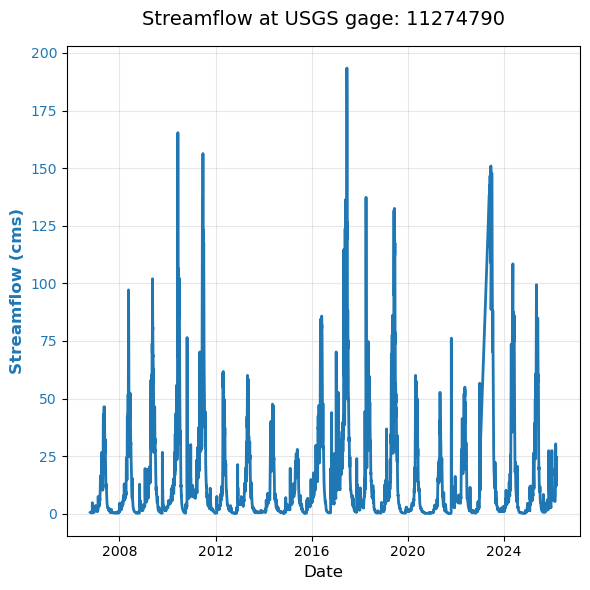

In [134]:
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: Streamflow ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Streamflow (cms)', color='tab:blue', fontsize=12, fontweight='bold')
ax1.plot(cleaned.index, cleaned['flow_cms'], color='tab:blue', label='Streamflow', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Title and Layout
plt.title('Streamflow at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()

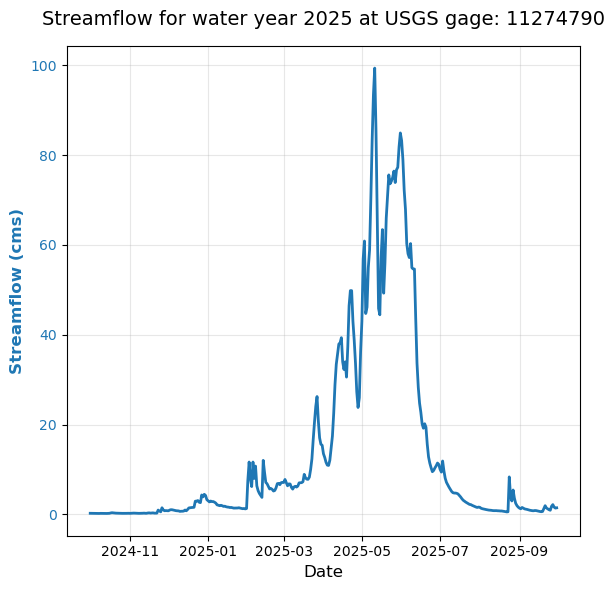

In [135]:
#clip the dataframe to show one single year
start = '2024-10-01'
end = '2025-09-30'
WY_df = cleaned.loc[start:end]

#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: Streamflow ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Streamflow (cms)', color='tab:blue', fontsize=12, fontweight='bold')
ax1.plot(WY_df.index, WY_df['flow_cms'], color='tab:blue', label='Streamflow', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Title and Layout
plt.title('Streamflow for water year 2025 at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()

## Get precipitation and temperature data for our area of interest using PyDayMet

In [ ]:
import earthaccess # note, you may need to create a .netrc file in you home directory with the following information
from pynhd import NLDI
import pydaymet as daymet

# Authenticate with NASA (only needed once per session)
earthaccess.login(persist=True)

# Get geometry and ensure CRS is correct
basin = NLDI().get_basins(usgs_gage_id)
geometry = basin.to_crs("EPSG:4326").geometry[0]
start_date = cleaned.index[0].strftime('%Y-%m-%d')
#select an end date that is at the end of the cleaned streamflow data or 2025-12-31, whatever is earlier
end_date = cleaned.index[-1].strftime('%Y-%m-%d')
if end_date > "2025-12-31":
    end_date = "2025-12-31"


var = ["prcp", "tmin", "tmax"]
dates = (start_date, end_date ) # Started with a smaller range to test

# Fetch data - authentication now happens automatically via earthaccess/.netrc
# Try this simplified call first
daily = daymet.get_bygeom(geometry=geometry, dates=dates, variables=["prcp"], validate_filesize=True)

#Note, there is a problem with the get_bygeom function related to the daymet url. All data has been transfered to NASA EarthData, and the URLs to not work. Point data seems to be working



In [136]:
import earthaccess # note, you may need to create a .netrc file in you home directory with the following information
from pynhd import NLDI
import pydaymet as daymet

#Authenticate with NASA (only needed once per session)
earthaccess.login(persist=True)

#Get geometry and ensure CRS is correct
basin = NLDI().get_basins(usgs_gage_id)
geometry_centroid = basin.to_crs("EPSG:4326").geometry[0].centroid
centroid = (geometry_centroid.x, geometry_centroid.y)

var = ["prcp", "tmin", "tmax"]
dates = (cleaned.index[0].strftime('%Y-%m-%d') , cleaned.index[-1].strftime('%Y-%m-%d') ) # Use the streamflow to determine dates

#Fetch data - authentication now happens automatically via earthaccess/.netrc
# Try this simplified call first
met_df = daymet.get_bycoords(centroid, dates, variables=["prcp", "tmin", "tmax"])



In [137]:
# clean the dataframe, rename the columns
met_df.rename(columns={"prcp (mm/day)": "prcp_mm_day", "tmin (degrees C)": "tmin_C", "tmax (degrees C)": "tmax_C"}, inplace=True)
#Calculate Mean Temperature
met_df["tmean"] = (met_df.tmax_C + met_df.tmin_C) / 2

#clip the dataframe by the streamflow dates
met_df = met_df.loc[cleaned.index[0]:cleaned.index[-1]]

#set the index to name to date
met_df.index.name = "Date"

met_df.head()


,prcp_mm_day,tmax_C,tmin_C,tmean
Date,,,,
2006-10-13,0.0,12.52,0.68,6.600
2006-10-14,0.0,12.76,-0.87,5.945
2006-10-15,0.0,15.72,-0.42,7.650
2006-10-16,0.0,9.39,-3.07,3.160
2006-10-17,0.0,5.66,-5.95,-0.145


## Put it all together into one dataframe

We want to create one data frame containing streamflow, meteological information, and SNOTEL for our period of record

In [139]:
#load snotel data
unprocessed_SNOTEL = {}
#read all files in the following path into the dictionary
path = 'files/SNOTEL'
for filename in os.listdir(path):
    if filename.endswith('.csv'):
        #select the name of the file between the _ and _
        name = filename.split('_')[1] 
        unprocessed_SNOTEL[name] = pd.read_csv(os.path.join(path, filename))
        #make the date a datetime object and set to the index
        unprocessed_SNOTEL[name]['Date'] = pd.to_datetime(unprocessed_SNOTEL[name]['Date'])
        unprocessed_SNOTEL[name].set_index('Date', inplace=True)
        #rename the Snow Water Equivalent (m) Start of Day Values to SWE_cm
        unprocessed_SNOTEL[name].rename(columns={'Snow Water Equivalent (m) Start of Day Values': f"{name}_SWE_cm"}, inplace=True)
        #convert SWE_m to cm
        unprocessed_SNOTEL[name][f"{name}_SWE_cm"] = unprocessed_SNOTEL[name][f"{name}_SWE_cm"] * 100
        #remove the Water_Year column
        unprocessed_SNOTEL[name].drop(columns=['Water_Year'], inplace=True)
        #we need to know how many obs for each DF, print the df name, its length, and the start/end dates
        print(f"{name}: {len(unprocessed_SNOTEL[name])} start date: {unprocessed_SNOTEL[name].index.min()} end date: {unprocessed_SNOTEL[name].index.max()}")
    



TUM: 6257 start date: 2004-10-01 00:00:00 end date: 2021-11-17 00:00:00
DAN: 6195 start date: 2004-10-01 00:00:00 end date: 2021-09-16 00:00:00
SLI: 5892 start date: 2005-10-01 00:00:00 end date: 2021-11-17 00:00:00
TES: 629 start date: 2005-03-01 00:00:00 end date: 2006-11-19 00:00:00


In [140]:
#The TES site is missing many values and will not be useful for our analysis, remove it
unprocessed_SNOTEL.pop('TES', None)

#The site with the latest start date will guide the rest
latest_start_date = max([df.index.min() for df in unprocessed_SNOTEL.values()])

#The site with the earliest end date will guide the rest
soonest_end_date = min([df.index.max() for df in unprocessed_SNOTEL.values()])
for key in unprocessed_SNOTEL.keys():
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index >= latest_start_date]
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index <= soonest_end_date]

#merge all dictionary dataframes into one larger dataframe
SNOTEL_df = pd.concat(unprocessed_SNOTEL.values(), axis=1)

SNOTEL_df.head()

,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm
Date,,,
2005-10-01,0.0,0.0,0.0
2005-10-02,0.0,0.0,0.0
2005-10-03,0.0,0.0,0.0
2005-10-04,0.0,0.0,0.0
2005-10-05,0.0,0.0,0.0


In [ ]:
met_df.head()

In [ ]:
cleaned.head()

In [141]:
#find the latest start date and the earliest end date for SNOTEL_df, met_df, cleaned
begin_date = max([df.index.min() for df in [SNOTEL_df, met_df, cleaned]])
end_date = min([df.index.max() for df in [SNOTEL_df, met_df, cleaned]])

#clip each dataframe to have the same begin and end dates
SNOTEL_df = SNOTEL_df[(SNOTEL_df.index >= begin_date) & (SNOTEL_df.index <= end_date)]
met_df = met_df[(met_df.index >= begin_date) & (met_df.index <= end_date)]
cleaned = cleaned[(cleaned.index >= begin_date) & (cleaned.index <= end_date)]

#merge the SNOTEL_df, met_df, and streamflow dataframes
Hydro_df = pd.concat([SNOTEL_df, met_df, cleaned], axis=1)
Hydro_df.head(50)

,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,prcp_mm_day,tmax_C,tmin_C,tmean,site_no,flow_cms
Date,,,,,,,,,
2006-10-13,0.000,0.000,0.000,0.00,12.52,0.68,6.600,11274790,0.611643
2006-10-14,0.000,0.000,0.000,0.00,12.76,-0.87,5.945,11274790,0.563504
2006-10-15,0.000,0.000,0.000,0.00,15.72,-0.42,7.650,11274790,0.538019
2006-10-16,0.000,0.000,0.000,0.00,9.39,-3.07,3.160,11274790,0.504039
2006-10-17,0.000,0.000,0.000,0.00,5.66,-5.95,-0.145,11274790,0.481386
2006-10-18,0.000,0.000,0.000,0.00,12.50,-7.01,2.745,11274790,0.464396
2006-10-19,0.000,0.000,0.000,0.00,14.91,-0.99,6.960,11274790,0.461564
2006-10-20,0.000,0.000,0.000,0.00,15.95,-0.15,7.900,11274790,0.447405
2006-10-21,0.000,0.000,0.000,0.00,16.50,-1.08,7.710,11274790,0.427584


In [142]:
#all of the NaN values here should be 0, fill them
Hydro_df = Hydro_df.fillna(0)
Hydro_df.head(50)

,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,prcp_mm_day,tmax_C,tmin_C,tmean,site_no,flow_cms
Date,,,,,,,,,
2006-10-13,0.000,0.000,0.000,0.00,12.52,0.68,6.600,11274790,0.611643
2006-10-14,0.000,0.000,0.000,0.00,12.76,-0.87,5.945,11274790,0.563504
2006-10-15,0.000,0.000,0.000,0.00,15.72,-0.42,7.650,11274790,0.538019
2006-10-16,0.000,0.000,0.000,0.00,9.39,-3.07,3.160,11274790,0.504039
2006-10-17,0.000,0.000,0.000,0.00,5.66,-5.95,-0.145,11274790,0.481386
2006-10-18,0.000,0.000,0.000,0.00,12.50,-7.01,2.745,11274790,0.464396
2006-10-19,0.000,0.000,0.000,0.00,14.91,-0.99,6.960,11274790,0.461564
2006-10-20,0.000,0.000,0.000,0.00,15.95,-0.15,7.900,11274790,0.447405
2006-10-21,0.000,0.000,0.000,0.00,16.50,-1.08,7.710,11274790,0.427584


In [143]:
#take a look around peak SWE to make sure we have snotel values, early season can be tricky to assess
Hydro_df.loc['2019-03-01':'2019-04-01']

,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,prcp_mm_day,tmax_C,tmin_C,tmean,site_no,flow_cms
Date,,,,,,,,,
2019-03-01,74.422,82.296,122.936,14.08,3.27,-3.54,-0.135,11274790,6.909299
2019-03-02,75.184,83.058,124.460,28.55,1.44,-2.81,-0.685,11274790,11.071869
2019-03-03,78.486,86.868,128.524,0.00,3.90,-4.79,-0.445,11274790,10.618800
2019-03-04,78.232,86.868,128.778,0.00,5.98,-6.06,-0.040,11274790,9.854246
2019-03-05,78.232,86.614,129.032,23.06,1.48,-5.03,-1.775,11274790,10.448899
2019-03-06,80.772,89.408,132.334,19.66,0.18,-4.36,-2.090,11274790,12.827510
2019-03-07,83.312,92.456,135.890,7.76,1.75,-9.75,-4.000,11274790,10.901968
2019-03-08,83.566,92.710,136.652,0.00,-3.42,-12.52,-7.970,11274790,8.919792
2019-03-09,83.312,92.710,136.906,3.88,-1.31,-13.60,-7.455,11274790,7.560586


In [144]:
Hydro_df.tail()

,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,prcp_mm_day,tmax_C,tmin_C,tmean,site_no,flow_cms
Date,,,,,,,,,
2021-09-12,0.0,0.0,0.0,0.0,22.28,6.00,14.14,11274790,0.236728
2021-09-13,0.0,0.0,0.0,0.0,22.73,4.29,13.51,11274790,0.302990
2021-09-14,0.0,0.0,0.0,0.0,22.50,6.30,14.40,11274790,0.275239
2021-09-15,0.0,0.0,0.0,0.0,21.18,6.10,13.64,11274790,0.251170
2021-09-16,0.0,0.0,0.0,0.0,19.71,4.79,12.25,11274790,0.223986


## Data exploration

<Axes: xlabel='Date'>

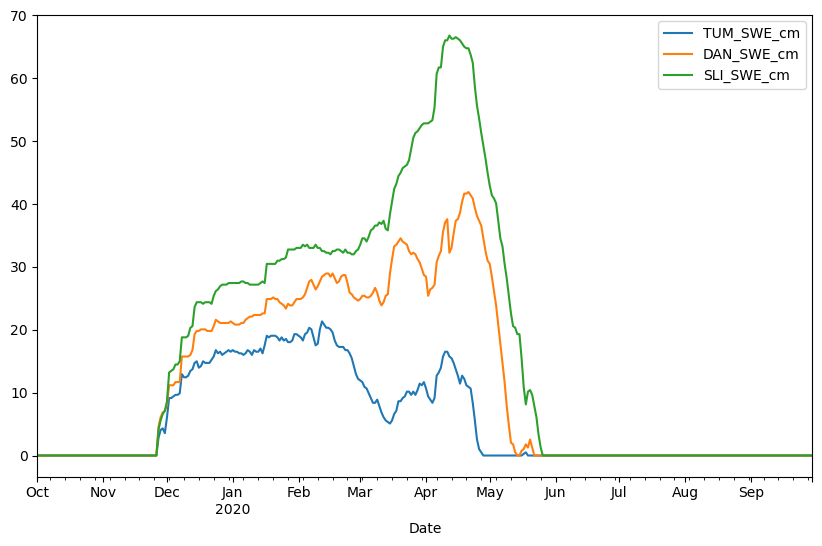

In [145]:
#For year 2019, plot all SWE_cm columns
SWE_df = Hydro_df.loc['2019-10-01':'2020-09-30'].copy()

#select all columns with 'SWE_cm' in the name
SWE_df = SWE_df.loc[:, SWE_df.columns.str.contains('SWE_cm')]

#plot
SWE_df.plot(figsize=(10, 6))

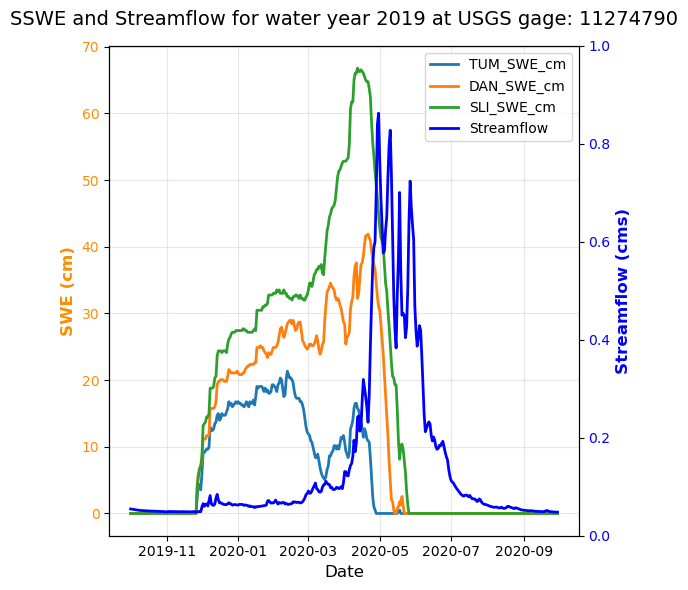

In [146]:
#plot the relationship between SWE_cm and flow_cms
#For year 2019, plot all SWE_cm columns
df = Hydro_df.loc['2019-10-01':'2020-09-30'].copy()

#select all columns with 'SWE_cm' and 'flow_cms' in the name
df = df.loc[:, df.columns.str.contains('SWE_cm') | df.columns.str.contains('flow_cms')]

#get colum names that contain SWE_cm
swe_cols = df.columns[df.columns.str.contains('SWE_cm')]

#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('SWE (cm)', color='darkorange', fontsize=12, fontweight='bold')
for swe in swe_cols:    
    ax1.plot(df.index, df[swe], linewidth=2, label = swe)

ax1.plot(df.index, df.flow_cms, color='blue', linewidth=2, label='Streamflow') 
ax1.tick_params(axis='y', labelcolor='darkorange')
ax1.grid(True, alpha=0.3)
#make second axis for streamflow
ax2 = ax1.twinx()
ax2.set_ylabel('Streamflow (cms)', color='blue', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

#show a legend
ax1.legend()

# Title and Layout
plt.title('SSWE and Streamflow for water year 2019 at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()


In [147]:
df.columns

Index(['TUM_SWE_cm', 'DAN_SWE_cm', 'SLI_SWE_cm', 'flow_cms'], dtype='object')

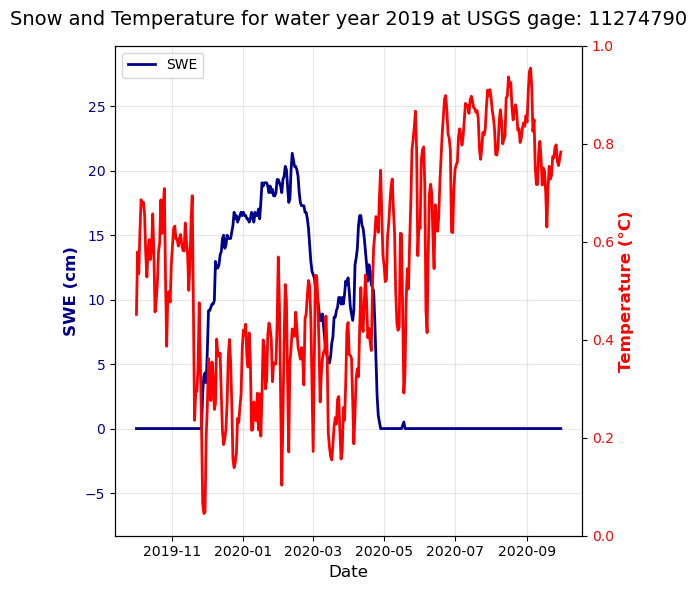

In [148]:
#plot the relationship between SWE_cm and temperature
#For year 2019, plot all SWE_cm columns
df = Hydro_df.loc['2019-10-01':'2020-09-30'].copy()

#get colum names that contain SWE_cm
swe_cols = df.columns[df.columns.str.contains('SWE_cm')]

#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('SWE (cm)', color='darkblue', fontsize=12, fontweight='bold')
#for swe in swe_cols:    
ax1.plot(df.index, df.TUM_SWE_cm, linewidth=2, label = 'SWE', color='darkblue')
ax1.plot(df.index, df.tmax_C, color='red', linewidth=2)

ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.grid(True, alpha=0.3)
#make second axis for streamflow
ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')

#show a legend
ax1.legend()

# Title and Layout
plt.title('Snow and Temperature for water year 2019 at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()


In [149]:
Hydro_df.columns

Index(['TUM_SWE_cm', 'DAN_SWE_cm', 'SLI_SWE_cm', 'prcp_mm_day', 'tmax_C',
       'tmin_C', 'tmean', 'site_no', 'flow_cms'],
      dtype='object')

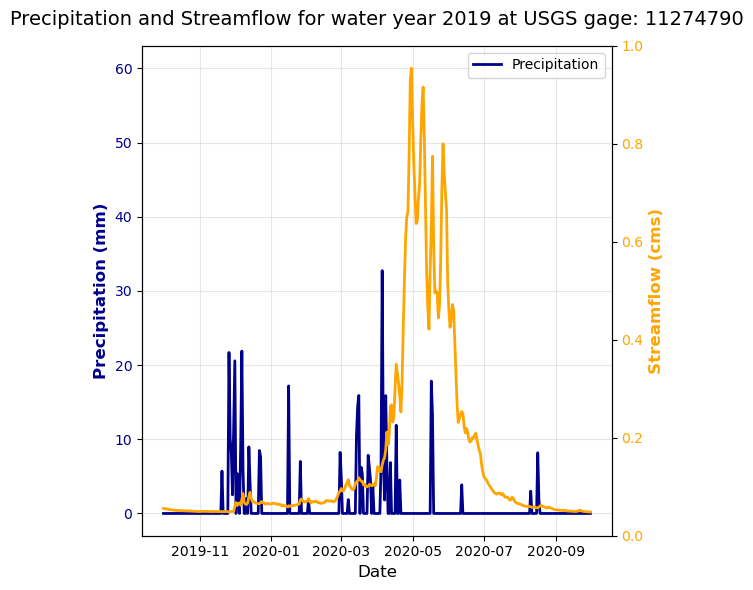

In [151]:
#plot the relationship between streamflow and precipitation
#For year 2019, plot all SWE_cm columns
df = Hydro_df.loc['2019-10-01':'2020-09-30'].copy()

#get colum names that contain SWE_cm
swe_cols = df.columns[df.columns.str.contains('SWE_cm')]

#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Precipitation (mm)', color='darkblue', fontsize=12, fontweight='bold')
#for swe in swe_cols:    
ax1.plot(df.index, df.prcp_mm_day, linewidth=2, label = 'Precipitation', color='darkblue')
ax1.plot(df.index, df.flow_cms, color='orange', linewidth=2)

ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.grid(True, alpha=0.3)
#make second axis for streamflow
ax2 = ax1.twinx()
ax2.set_ylabel('Streamflow (cms)', color='orange', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='orange')

#show a legend
ax1.legend()

# Title and Layout
plt.title('Precipitation and Streamflow for water year 2019 at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()
